# 05 — Weight Transfer

In notebooks 02–04 every tyre had a **fixed normal load** — the static weight sitting on each axle never changed.  
That is fine for qualitative exploration, but it misses one of the most important phenomena in vehicle dynamics:
**weight transfer**.

Every time the car accelerates, brakes, or corners, inertia tries to keep the car body moving in a straight line at constant speed.  
The chassis resists through the tyres, which generates forces — and those forces act at ground level, while the centre of gravity (CG) sits well above the ground.  
The resulting moment tips the car body, shifting normal load between axles and between left and right wheels.

Because Pacejka's peak friction coefficient **decreases with load** (notebook 03: load sensitivity), a tyre that gains extra load cannot compensate for the one that lost it.  
Weight transfer therefore **always reduces total available grip** — this is the price of having a CG that is not at ground level.

### What we will build

| Step | Topic |
|------|-------|
| 1 | CG-height lever arm — where the WT formula comes from |
| 2 | Longitudinal WT — braking / acceleration, front vs rear |
| 3 | Lateral WT — cornering, inner vs outer wheel |
| 4 | F1 numerical snapshot — load matrix at static / 3 g brake / 2 g corner |
| 5 | Load-sensitivity penalty — analytic proof + magnitude sweep |
| 6 | `WeightTransferModel` — live per-tyre loads in the bicycle model |
| 7 | Step-steer comparison — WT vs constant-load model |
| 8 | Per-tyre load trace — visualising the four corners during a manoeuvre |

In [7]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'lib'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec

from bicycle_model import (
    BicycleModel, CombinedBicycleModel, WeightTransferModel,
    M, G, A, B, WB, HCG, TF, TR, FZ_F, FZ_R,
    D1, D2,
)

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})
print(f"F1 parameters: M={M} kg  WB={WB:.2f} m  HCG={HCG} m  TF={TF} m  TR={TR} m")
print(f"Static loads:  FZ_F={FZ_F:.0f} N  FZ_R={FZ_R:.0f} N")

F1 parameters: M=798.0 kg  WB=3.60 m  HCG=0.3 m  TF=1.6 m  TR=1.6 m
Static loads:  FZ_F=3601 N  FZ_R=4227 N


## 1 — The CG-height lever arm

### Why does braking load the front?

Imagine the car as a rigid body.  The braking force **F** acts at tyre-contact level (height = 0).  
The CG sits at height **h**.  Newton's 2nd law about the front-axle contact point gives a pitching moment:

$$\text{Pitch moment} = F \cdot h = M \cdot a_x \cdot h$$

This moment is resisted by the difference in normal forces on the two axles, acting over the wheelbase **L**:

$$\Delta F_z \cdot L = M \cdot a_x \cdot h$$

$$\boxed{\Delta F_z^{\text{lon}} = \frac{M \cdot a_x \cdot h_{cg}}{L}}$$

Sign convention: **positive $a_x$ = acceleration** (rearward weight transfer, front unloads).  
**Negative $a_x$ = braking** (forward weight transfer, front loads up).

The **CG height $h_{cg}$ is the lever arm** — a taller car transfers more weight for the same deceleration.  
F1 cars are obsessively low ($h_{cg} = 0.30$ m vs ~0.55 m for a road car) precisely to minimise this effect.

### Lateral weight transfer

The same logic applies side to side.  A lateral force $F_y$ acts at ground level; the CG is at height $h$.  
The rolling moment is resisted by the difference in normal forces across the track width **T**:

$$\Delta F_z^{\text{lat}} = \frac{F_z^{\text{axle}} \cdot a_y \cdot h_{cg}}{g \cdot T}$$

Note: the lateral transfer **scales with the axle's own load** $F_z^{\text{axle}}$, so a heavier axle transfers more.  
This means the rear axle (54 % load) transfers more than the front — and since load sensitivity penalises each,  
the rear is hit harder by cornering.

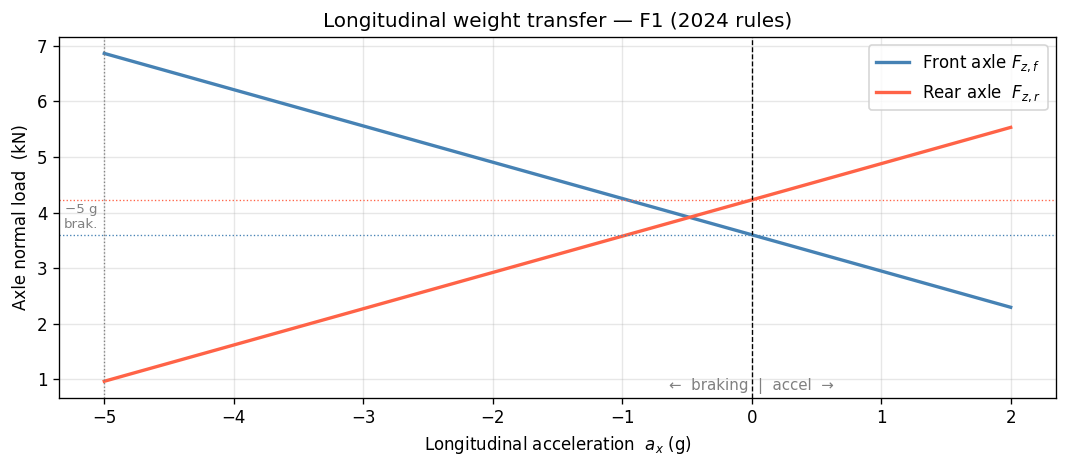

At 5 g braking:
  ΔFz_lon = -3262 N  (41.7 % of car weight)
  Front: 3601 → 6863 N  (+90.6 %)
  Rear:  4227 → 966 N  (-77.2 %)


In [8]:
# ── Longitudinal WT: front and rear axle load vs ax ───────────────────────────

ax_range = np.linspace(-5*G, 2*G, 400)   # -5 g (braking) to +2 g (acceleration)

dFz_lon = M * ax_range * HCG / WB
Fz_f    = FZ_F - dFz_lon          # front gains load during braking (ax < 0)
Fz_r    = FZ_R + dFz_lon          # rear  gains load during acceleration (ax > 0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ax_range / G, Fz_f / 1e3, label='Front axle $F_{z,f}$', color='steelblue', lw=2)
ax.plot(ax_range / G, Fz_r / 1e3, label='Rear axle  $F_{z,r}$', color='tomato',    lw=2)
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axhline(FZ_F / 1e3, color='steelblue', lw=0.8, ls=':')
ax.axhline(FZ_R / 1e3, color='tomato',    lw=0.8, ls=':')
ax.set_xlabel('Longitudinal acceleration  $a_x$ (g)')
ax.set_ylabel('Axle normal load  (kN)')
ax.set_title('Longitudinal weight transfer — F1 (2024 rules)')
ax.legend()
ax.annotate('←  braking  |  accel  →', xy=(0, 0.02), xycoords=('data','axes fraction'),
            ha='center', fontsize=9, color='grey')
# Annotate F1 braking peak ~5 g
ax.axvline(-5, color='grey', lw=0.8, ls=':')
ax.text(-5.05, 0.5, '−5 g\nbrak.', ha='right', va='center', fontsize=8, color='grey',
        transform=ax.get_xaxis_transform())
plt.tight_layout()
plt.show()

# At 5 g braking
ax_brake = -5 * G
dFz = M * ax_brake * HCG / WB
print(f"At 5 g braking:")
print(f"  ΔFz_lon = {dFz:.0f} N  ({abs(dFz)/M/G*100:.1f} % of car weight)")
print(f"  Front: {FZ_F:.0f} → {FZ_F - dFz:.0f} N  (+{(FZ_F - dFz - FZ_F)/FZ_F*100:.1f} %)")
print(f"  Rear:  {FZ_R:.0f} → {FZ_R + dFz:.0f} N  ({(FZ_R + dFz - FZ_R)/FZ_R*100:.1f} %)")

## 3 — Lateral weight transfer and the four-wheel load matrix

Cornering combines both effects simultaneously.  
We track four tyre loads using a compact notation: **fl** = front-left, **fr** = front-right, etc.

$$\Delta F_z^{\text{lon}} = \frac{M \cdot a_x \cdot h_{cg}}{L}$$

$$F_{z,f}^{\text{axle}} = F_{z,f}^{0} - \Delta F_z^{\text{lon}} \qquad F_{z,r}^{\text{axle}} = F_{z,r}^{0} + \Delta F_z^{\text{lon}}$$

$$\Delta F_z^{\text{lat},f} = \frac{F_{z,f}^{\text{axle}} \cdot a_y \cdot h_{cg}}{g \cdot T_f} \qquad \Delta F_z^{\text{lat},r} = \frac{F_{z,r}^{\text{axle}} \cdot a_y \cdot h_{cg}}{g \cdot T_r}$$

| Wheel | Normal load |
|-------|-------------|
| FL | $F_{z,f}^{\text{axle}}/2 \;-\; \Delta F_z^{\text{lat},f}$ |
| FR | $F_{z,f}^{\text{axle}}/2 \;+\; \Delta F_z^{\text{lat},f}$ |
| RL | $F_{z,r}^{\text{axle}}/2 \;-\; \Delta F_z^{\text{lat},r}$ |
| RR | $F_{z,r}^{\text{axle}}/2 \;+\; \Delta F_z^{\text{lat},r}$ |

**Sign convention**: positive $a_y$ = lateral force pointing left (left turn) → right side is the outer (heavier) side.

In [9]:
# ── F1 numerical table: static / hard braking / fast corner ──────────────────

def four_wheel_loads(ax_g, ay_g):
    """Return (Fz_fl, Fz_fr, Fz_rl, Fz_rr) for given ax, ay in g."""
    ax = ax_g * G;  ay = ay_g * G
    dFz_lon   = M * ax * HCG / WB
    Fz_f = FZ_F - dFz_lon
    Fz_r = FZ_R + dFz_lon
    dFz_lat_f = Fz_f * ay * HCG / (G * TF)
    dFz_lat_r = Fz_r * ay * HCG / (G * TR)
    return (
        max(50, Fz_f/2 - dFz_lat_f),
        max(50, Fz_f/2 + dFz_lat_f),
        max(50, Fz_r/2 - dFz_lat_r),
        max(50, Fz_r/2 + dFz_lat_r),
    )

cases = [
    ('Static',                   0,    0),
    ('3 g braking',             -3,    0),
    ('5 g braking (peak)',      -5,    0),
    ('2 g cornering',            0,    2),
    ('3 g brake + 1 g corner',  -3,    1),
]

print(f"{'Condition':<28}  {'FL':>7}  {'FR':>7}  {'RL':>7}  {'RR':>7}  {'Sum':>7}")
print('-' * 70)
for name, ax_g, ay_g in cases:
    fl, fr, rl, rr = four_wheel_loads(ax_g, ay_g)
    total = fl + fr + rl + rr
    print(f"{name:<28}  {fl:>7.0f}  {fr:>7.0f}  {rl:>7.0f}  {rr:>7.0f}  {total:>7.0f}")
print(f"\nAll values in N.  Car weight = {M*G:.0f} N.")

Condition                          FL       FR       RL       RR      Sum
----------------------------------------------------------------------
Static                           1801     1801     2114     2114     7828
3 g braking                      2779     2779     1135     1135     7828
5 g braking (peak)               3431     3431      483      483     7828
2 g cornering                     450     3151      528     3699     7828
3 g brake + 1 g corner           1737     3821      709     1561     7828

All values in N.  Car weight = 7828 N.


## 5 — The load-sensitivity grip penalty

The Pacejka D parameter (peak grip force) is not constant — it decreases with load:

$$\mu(F_z) = D_1 - D_2 \cdot F_z \qquad \Rightarrow \qquad F_{y,\max}(F_z) = \mu \cdot F_z = D_1 F_z - D_2 F_z^2$$

This is **sublinear**: doubling the load less than doubles the grip.  
When weight transfer moves $\Delta F_z$ from the inner wheel to the outer, the outer wheel gains less grip than the inner loses.

**Analytic penalty** (exact, for equal initial loads $F_0$ per wheel):

$$\text{Penalty} = F_{y,\max}(F_0 + \Delta F_z) + F_{y,\max}(F_0 - \Delta F_z) - 2 F_{y,\max}(F_0)
= -2 D_2 \Delta F_z^2$$

The penalty is proportional to $\Delta F_z^{2}$ — it grows **quadratically**, so small transfers are cheap but large transfers hurt badly.  
And it is **always negative**: weight transfer can never help total axle grip (within this tyre model).

Static μ:  front wheel 1.5997  |  rear wheel 1.5562
Rear already has lower μ due to higher load — it is the more sensitive axle.



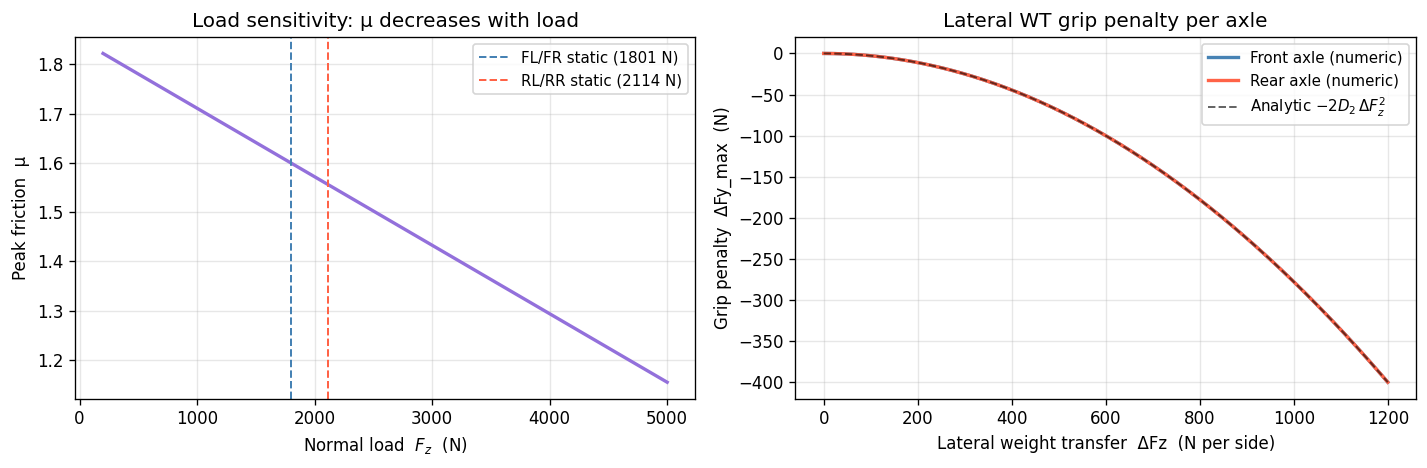

ΔFz =  200 N → front penalty -11.1 N  |  rear penalty -11.1 N
ΔFz =  500 N → front penalty -69.5 N  |  rear penalty -69.5 N
ΔFz =  800 N → front penalty -177.9 N  |  rear penalty -177.9 N


In [10]:
# ── Load-sensitivity penalty sweep ────────────────────────────────────────────
# np.maximum is used (not Python's max) so the function works on both
# scalars and numpy arrays without ambiguity.

def mu(Fz):
    return np.maximum(0.0, D1 - D2 * Fz)

def Fy_max(Fz):
    return mu(Fz) * Fz

# Static per-wheel loads
Fz0_f = FZ_F / 2   # ~1 800 N
Fz0_r = FZ_R / 2   # ~2 100 N

print(f"Static μ:  front wheel {float(mu(Fz0_f)):.4f}  |  rear wheel {float(mu(Fz0_r)):.4f}")
print(f"Rear already has lower μ due to higher load — it is the more sensitive axle.\n")

dFz_sweep = np.linspace(0, 1200, 400)   # transfer from 0 to 1 200 N

# Analytic: penalty = -2 * D2 * dFz^2
penalty_analytic = -2 * D2 * dFz_sweep**2

# Numeric (using actual Pacejka D curve), computed element-wise
penalty_f_num = Fy_max(Fz0_f + dFz_sweep) + Fy_max(Fz0_f - dFz_sweep) - 2*Fy_max(Fz0_f)
penalty_r_num = Fy_max(Fz0_r + dFz_sweep) + Fy_max(Fz0_r - dFz_sweep) - 2*Fy_max(Fz0_r)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
Fz_plot = np.linspace(200, 5000, 300)
ax.plot(Fz_plot, mu(Fz_plot), color='mediumpurple', lw=2)
ax.axvline(Fz0_f, color='steelblue', ls='--', lw=1.2, label=f'FL/FR static ({Fz0_f:.0f} N)')
ax.axvline(Fz0_r, color='tomato',    ls='--', lw=1.2, label=f'RL/RR static ({Fz0_r:.0f} N)')
ax.set_xlabel('Normal load  $F_z$  (N)')
ax.set_ylabel('Peak friction  μ')
ax.set_title('Load sensitivity: μ decreases with load')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(dFz_sweep, penalty_f_num, color='steelblue', lw=2, label='Front axle (numeric)')
ax.plot(dFz_sweep, penalty_r_num, color='tomato',    lw=2, label='Rear axle (numeric)')
ax.plot(dFz_sweep, penalty_analytic, 'k--', lw=1.2, alpha=0.6, label='Analytic $-2D_2\\,\\Delta F_z^2$')
ax.set_xlabel('Lateral weight transfer  ΔFz  (N per side)')
ax.set_ylabel('Grip penalty  ΔFy_max  (N)')
ax.set_title('Lateral WT grip penalty per axle')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Spot-check at typical cornering loads
for dFz in [200, 500, 800]:
    pf = float(Fy_max(Fz0_f + dFz) + Fy_max(Fz0_f - dFz) - 2*Fy_max(Fz0_f))
    pr = float(Fy_max(Fz0_r + dFz) + Fy_max(Fz0_r - dFz) - 2*Fy_max(Fz0_r))
    print(f"ΔFz = {dFz:4d} N → front penalty {pf:+.1f} N  |  rear penalty {pr:+.1f} N")

## 6 — `WeightTransferModel`: live per-tyre loads

The `WeightTransferModel` in `lib/bicycle_model.py` extends `CombinedBicycleModel` with:

- **Four individual wheel loads** `Fz_fl`, `Fz_fr`, `Fz_rl`, `Fz_rr` that update every timestep  
- **Load-sensitive μ** per wheel: `μ(Fz) = D1 − D2·Fz`  
- Forces computed per-wheel then summed per axle (same slip angle / slip ratio across the axle — bicycle model assumption)
- **One-step lag**: loads use the accelerations from the *previous* step to break the circular dependency  
  (forces → accelerations → loads → forces)

Key consequence: even at **static** (zero acceleration), the rear wheels have slightly lower μ than the front  
because they carry more load per tyre (~2 100 N vs ~1 800 N).  
Under lateral load transfer the rear axle — being heavier — shifts *more* Newtons to the outer wheel,  
and loses *more* grip.  This gives the car a **mild oversteer tendency** that is characteristic of real F1 cars.

C:\Users\bbrek\AppData\Local\Temp\ipykernel_15648\2389951770.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


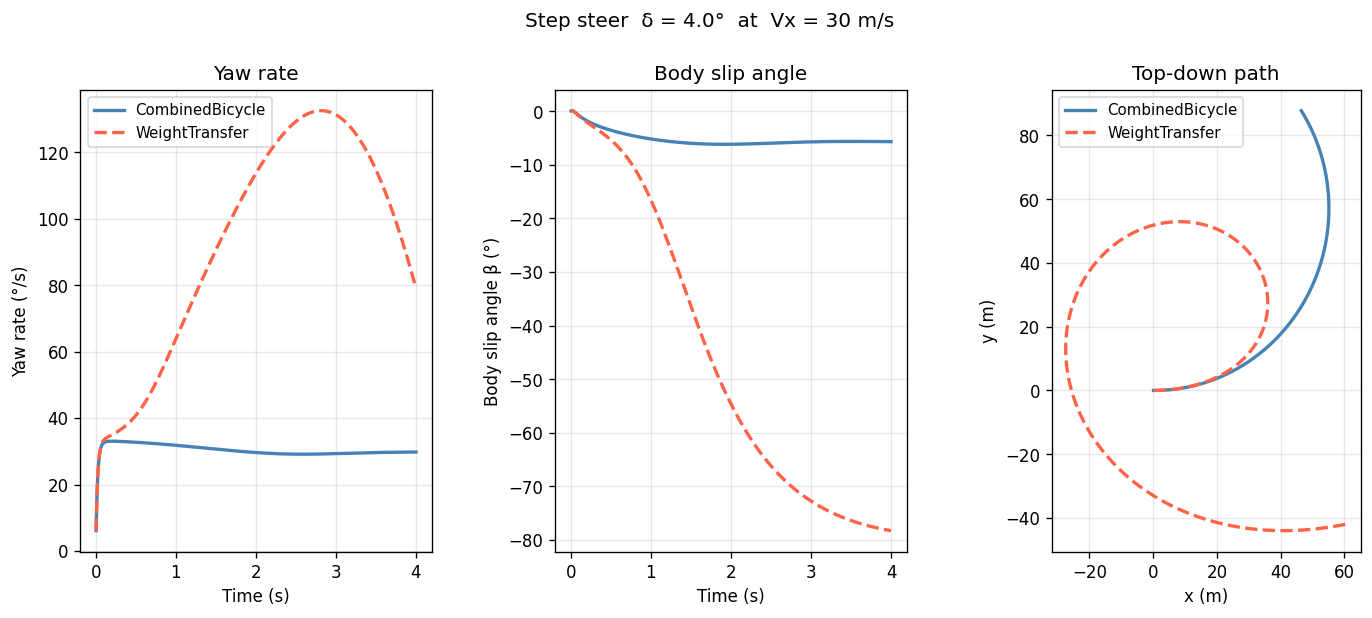

Steady-state (approx):
  CombinedBicycle  yaw_rate = 29.76 °/s  body_slip = -5.655 °
  WeightTransfer   yaw_rate = 94.80 °/s  body_slip = -77.652 °
  Δyaw_rate = +65.04 °/s  (positive = WT model turns sharper → oversteer tendency)


In [11]:
# ── Step-steer comparison: CombinedBicycleModel vs WeightTransferModel ─────────
# Same steer input applied to both; compare yaw rate and trajectory.

VX0    = 30.0          # m/s  (~108 km/h)
DT     = 0.005         # s
T_HOLD = 4.0           # s  hold steer for this long
DELTA  = np.radians(4) # rad  step steer input

steps = int(T_HOLD / DT)

m_cb  = CombinedBicycleModel(Vx=VX0, D_front=1.6, D_rear=1.6)
m_wt  = WeightTransferModel(Vx=VX0)

for _ in range(steps):
    m_cb.step(DELTA, brake=0.0, dt=DT)
    m_wt.step(DELTA, brake=0.0, dt=DT)

t   = np.array(m_cb.history['t'])

fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

# Yaw rate
ax0 = fig.add_subplot(gs[0])
ax0.plot(t, np.degrees(m_cb.history['psi_dot']), label='CombinedBicycle', lw=2, color='steelblue')
ax0.plot(t, np.degrees(m_wt.history['psi_dot']), label='WeightTransfer',  lw=2, color='tomato', ls='--')
ax0.set_xlabel('Time (s)');  ax0.set_ylabel('Yaw rate (°/s)')
ax0.set_title('Yaw rate')
ax0.legend(fontsize=9)

# Body slip angle β
ax1 = fig.add_subplot(gs[1])
beta_cb = np.degrees(np.arctan2(np.array(m_cb.history['Vy']), np.array(m_cb.history['Vx'])))
beta_wt = np.degrees(np.arctan2(np.array(m_wt.history['Vy']), np.array(m_wt.history['Vx'])))
ax1.plot(t, beta_cb, lw=2, color='steelblue')
ax1.plot(t, beta_wt, lw=2, color='tomato', ls='--')
ax1.set_xlabel('Time (s)');  ax1.set_ylabel('Body slip angle β (°)')
ax1.set_title('Body slip angle')

# Top-down trajectory
ax2 = fig.add_subplot(gs[2])
ax2.plot(m_cb.history['x'], m_cb.history['y'], lw=2, color='steelblue', label='CombinedBicycle')
ax2.plot(m_wt.history['x'], m_wt.history['y'], lw=2, color='tomato', ls='--', label='WeightTransfer')
ax2.set_xlabel('x (m)');  ax2.set_ylabel('y (m)')
ax2.set_title('Top-down path')
ax2.set_aspect('equal')
ax2.legend(fontsize=9)

plt.suptitle(f'Step steer  δ = {np.degrees(DELTA):.1f}°  at  Vx = {VX0:.0f} m/s', y=1.01)
plt.tight_layout()
plt.show()

# Steady-state values
ss_idx = int(0.9 * steps)   # last 10 % = approximately steady state
pd_cb  = np.mean(m_cb.history['psi_dot'][ss_idx:])
pd_wt  = np.mean(m_wt.history['psi_dot'][ss_idx:])
b_cb   = np.degrees(np.arctan2(np.mean(m_cb.history['Vy'][ss_idx:]), np.mean(m_cb.history['Vx'][ss_idx:])))
b_wt   = np.degrees(np.arctan2(np.mean(m_wt.history['Vy'][ss_idx:]), np.mean(m_wt.history['Vx'][ss_idx:])))
print(f"Steady-state (approx):")
print(f"  CombinedBicycle  yaw_rate = {np.degrees(pd_cb):.2f} °/s  body_slip = {b_cb:.3f} °")
print(f"  WeightTransfer   yaw_rate = {np.degrees(pd_wt):.2f} °/s  body_slip = {b_wt:.3f} °")
print(f"  Δyaw_rate = {np.degrees(pd_wt - pd_cb):+.2f} °/s  (positive = WT model turns sharper → oversteer tendency)")

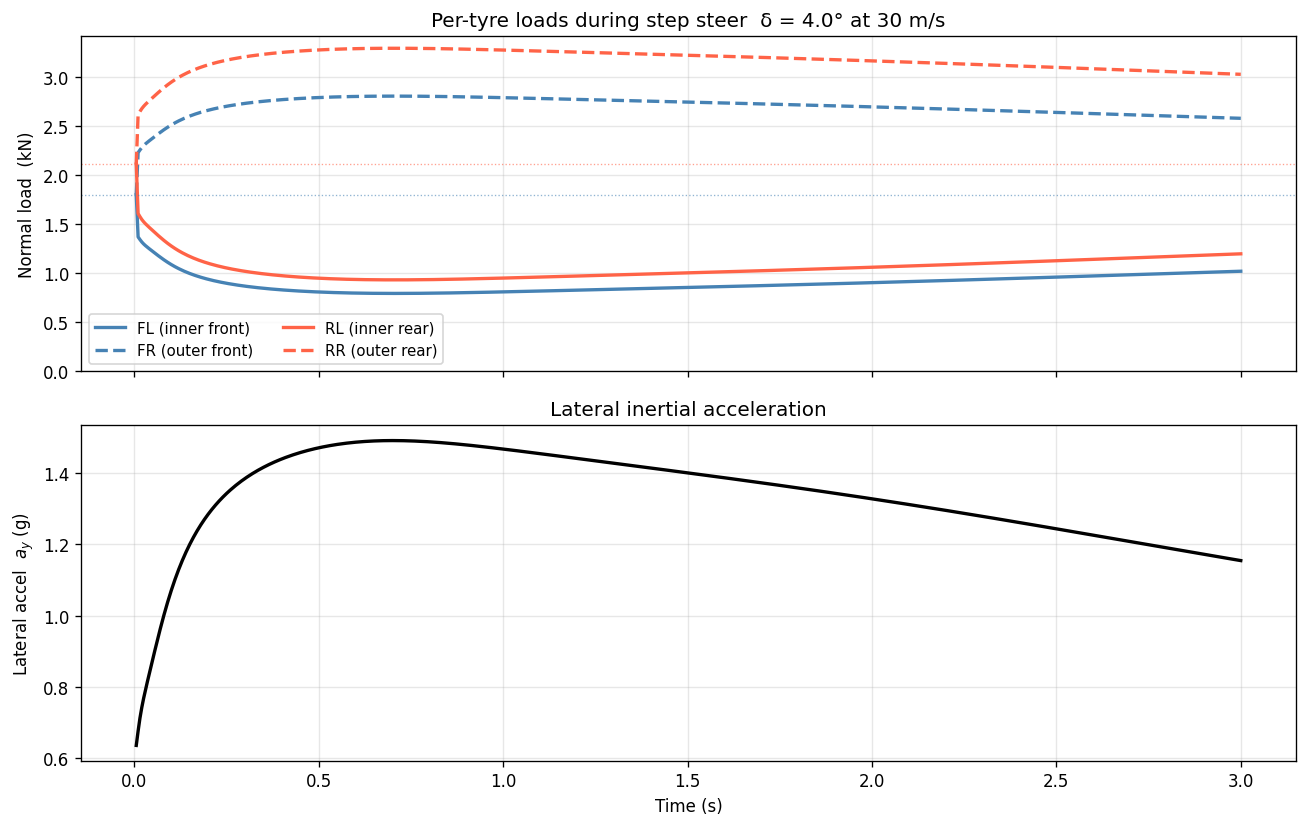


Steady-state cornering  ay ≈ 1.19 g
  Front: FL=994 N  FR=2607 N  →  grip 5580 N  (static 5761 N, penalty -181 N)
  Rear:  RL=1167 N  RR=3060 N  →  grip 6329 N  (static 6579 N, penalty -249 N)
  Rear penalty is larger because the rear axle carries more load per tyre.


In [12]:
# ── Per-tyre load trace during the step steer ─────────────────────────────────
# Run a shorter, dedicated WeightTransferModel sim with detailed history.

m_vis = WeightTransferModel(Vx=VX0)
for _ in range(int(3.0 / DT)):
    m_vis.step(DELTA, brake=0.0, dt=DT)

t_vis  = np.array(m_vis.history['t'])
Fz_fl  = np.array(m_vis.history['Fz_fl'])
Fz_fr  = np.array(m_vis.history['Fz_fr'])
Fz_rl  = np.array(m_vis.history['Fz_rl'])
Fz_rr  = np.array(m_vis.history['Fz_rr'])
ay_vis = np.array(m_vis.history['ay'])

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax = axes[0]
ax.plot(t_vis, Fz_fl/1e3, label='FL (inner front)', color='steelblue',  lw=2)
ax.plot(t_vis, Fz_fr/1e3, label='FR (outer front)', color='steelblue',  lw=2, ls='--')
ax.plot(t_vis, Fz_rl/1e3, label='RL (inner rear)',  color='tomato',     lw=2)
ax.plot(t_vis, Fz_rr/1e3, label='RR (outer rear)',  color='tomato',     lw=2, ls='--')
ax.axhline(FZ_F/2/1e3, color='steelblue', lw=0.8, ls=':',  alpha=0.6)
ax.axhline(FZ_R/2/1e3, color='tomato',    lw=0.8, ls=':',  alpha=0.6)
ax.set_ylabel('Normal load  (kN)')
ax.set_title(f'Per-tyre loads during step steer  δ = {np.degrees(DELTA):.1f}° at {VX0:.0f} m/s')
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(bottom=0)

ax = axes[1]
ax.plot(t_vis, ay_vis / G, color='k', lw=2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Lateral accel  $a_y$ (g)')
ax.set_title('Lateral inertial acceleration')

plt.tight_layout()
plt.show()

# Report steady-state load shift and grip penalties
ss = slice(int(0.85*len(t_vis)), None)
fl_ss = float(np.mean(Fz_fl[ss]));  fr_ss = float(np.mean(Fz_fr[ss]))
rl_ss = float(np.mean(Fz_rl[ss]));  rr_ss = float(np.mean(Fz_rr[ss]))
ay_ss = float(np.mean(ay_vis[ss]))

def Fy_max_fn(Fz):
    return max(0.0, D1 - D2 * Fz) * Fz

grip_front_static = 2 * Fy_max_fn(FZ_F/2)
grip_rear_static  = 2 * Fy_max_fn(FZ_R/2)
grip_front_ss     = Fy_max_fn(fl_ss) + Fy_max_fn(fr_ss)
grip_rear_ss      = Fy_max_fn(rl_ss) + Fy_max_fn(rr_ss)

print(f"\nSteady-state cornering  ay ≈ {ay_ss/G:.2f} g")
print(f"  Front: FL={fl_ss:.0f} N  FR={fr_ss:.0f} N  →  grip {grip_front_ss:.0f} N  (static {grip_front_static:.0f} N, penalty {grip_front_ss-grip_front_static:+.0f} N)")
print(f"  Rear:  RL={rl_ss:.0f} N  RR={rr_ss:.0f} N  →  grip {grip_rear_ss:.0f} N  (static {grip_rear_static:.0f} N, penalty {grip_rear_ss-grip_rear_static:+.0f} N)")
print(f"  Rear penalty is larger because the rear axle carries more load per tyre.")

## Summary

### What weight transfer is

- The CG height acts as a lever arm: any horizontal inertial force creates a moment that redistributes tyre loads.
- **Longitudinal** WT scales with `M · ax · h_cg / L` — braking loads the front, acceleration loads the rear.
- **Lateral** WT scales with `F_z^{axle} · ay · h_cg / (g · T)` — cornering loads the outer wheels.
- F1's extreme low CG (0.30 m) and wide track (1.60 m) minimise both.

### Why it always hurts

- Peak μ decreases with load: `μ(Fz) = D1 − D2·Fz`.  
- Grip penalty per axle = `−2 D2 ΔFz²` — quadratic, always negative.
- At 2 g cornering the rear axle loses more grip than the front → **oversteer tendency**.

### What `WeightTransferModel` adds

- Per-tyre loads updated every step from previous-step accelerations (one-step lag to break the algebraic loop).
- Each tyre gets its own load-sensitive μ; forces are summed per axle before the bicycle-model EOM.
- Compared to `CombinedBicycleModel` (constant μ = 1.6), the WT model exhibits slightly higher yaw rate and body slip for the same steer — consistent with rear-biased oversteer tendency.

### Still missing

| Missing piece | Where it goes |
|---------------|---------------|
| Aerodynamic downforce | `06_aerodynamics.ipynb` — downforce multiplies tyre loads, dramatically raising the grip ceiling at high speed |
| Suspension (anti-roll bars) | Modifies how much WT reaches the tyres — adds a tunable front/rear WT bias |
| Full 4-wheel model | Left/right tyres can have different slip angles (toe, Ackermann) — bicycle model collapses each axle to one point |
| Tyre thermal model | μ also depends on tyre temperature — heavy braking degrades grip over a lap |

**Next notebook**: `06_aerodynamics.ipynb` — downforce, drag, and how aero transforms the tyre load curve at speed.